## News Sentiment and NVDA Stock Price EDA

In [ ]:
import sys
import os

sys.path.insert(0, os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_1/news-sentiment-analysis'))

print('Path set. Python will now look in:', os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_1/news-sentiment-analysis'))

Path set. Python will now look in: C:\Users\dagic\OneDrive\Documents\KAIM\Week_1\news-sentiment-analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from nltk.sentiment import SentimentIntensityAnalyzer
from scipy.stats import pearsonr

import nltk as nltk

In [2]:
# Download VADER lexicon 
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
news_df = pd.read_csv("../../../data/processed/cleaned_raw_analyst_ratings.csv")

C:\Users\dagic\AppData\Local\Temp\ipykernel_9932\886886978.py:1: DtypeWarning: Columns (0: date) have mixed types. Specify dtype option on import or set low_memory=False.
  news_df = pd.read_csv("../../../data/processed/cleaned_raw_analyst_ratings.csv")


In [4]:
news_df.head()

,date,Unnamed: 0,headline,url,publisher,stock
0,2011-04-27 21:01:48-04:00,357064,"ETFs To Watch April 28, 2011 (DGP, IEO, PRN, IDX)",https://www.benzinga.com/etfs/bond-etfs/11/04/...,ETF Professor,DGP
1,2011-04-28 13:49:29-04:00,437774,A New Regional Emerging Markets ETF,https://www.benzinga.com/etfs/emerging-market-...,Sam Subramanian,ESR
2,2011-04-28 15:00:36-04:00,350150,Dejour Extends Credit Facility to October 31st...,https://www.benzinga.com/news/11/04/1041764/de...,Theo Kratz,DEJ
3,2011-04-29 13:47:06-04:00,49280,"ETF Showdown: Crouching Tigers, Hidden ETFs",https://www.benzinga.com/etfs/emerging-market-...,ETF Professor,AIA
4,2011-04-29 16:11:05-04:00,539428,The GDL Fund to Redeem Its Outstanding 8.50% S...,https://www.benzinga.com/news/11/04/1045464/th...,Benzinga Staff,GDL


In [5]:
stock_df = pd.read_csv("../../../data/processed/cleaned_NVDA.csv", parse_dates=['date'])

In [6]:
stock_df.head()

,date,Close,High,Low,Open,Volume
0,2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000
1,2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000
2,2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000
3,2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000
4,2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000


In [7]:
print(stock_df.dtypes)

date      datetime64[us]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object


In [8]:
# Extract only calendar date
stock_df['date'] = stock_df['date'].dt.date

In [9]:
print(news_df.dtypes)

date            str
Unnamed: 0    int64
headline        str
url             str
publisher       str
stock           str
dtype: object


In [10]:
news_df['date'] = pd.to_datetime(news_df['date']).dt.normalize()

In [11]:
print(news_df.dtypes)

date          datetime64[us, UTC-04:00]
Unnamed: 0                        int64
headline                            str
url                                 str
publisher                           str
stock                               str
dtype: object


In [12]:
news_df['date'] = pd.to_datetime(news_df['date'])

In [13]:
# Extract only calendar date
news_df['date'] = news_df['date'].dt.date

In [14]:
news_df['date'] = pd.to_datetime(news_df['date']).dt.normalize()
stock_df['date'] = pd.to_datetime(stock_df['date']).dt.normalize()

In [15]:
print('news_df')
print(news_df.dtypes)

print('stock_df')
print(stock_df.dtypes)

news_df
date          datetime64[s]
Unnamed: 0            int64
headline                str
url                     str
publisher               str
stock                   str
dtype: object
stock_df
date      datetime64[s]
Close           float64
High            float64
Low             float64
Open            float64
Volume            int64
dtype: object


In [16]:
# HANDLE WEEKENDS / HOLIDAYS

# Get valid trading dates
trading_dates = sorted(stock_df['date'].unique())

# Function to map news dates to next trading day
def align_to_trading_day(news_date):

    for trade_date in trading_dates:

        if trade_date >= news_date:
            return trade_date

    return np.nan

In [17]:
# Align dates in news_df to trading days
news_df['trading_date'] = news_df['date'].apply(align_to_trading_day)

## SENTIMENT ANALYSIS USING VADER

In [18]:
sia = SentimentIntensityAnalyzer()

# Compute sentiment score
news_df['sentiment_score'] = news_df['headline'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

## DAILY AVERAGE SENTIMENT

In [19]:
daily_sentiment = (
    news_df
    .groupby('trading_date')['sentiment_score']
    .mean()
    .reset_index()
)

daily_sentiment.rename(
    columns={'trading_date': 'date'},
    inplace=True
)

## DAILY STOCK RETURNS

In [20]:
stock_df['Daily_Return'] = (
    stock_df['Close'].pct_change() * 100
)

## MERGE DATASETS

In [21]:
merged_df = pd.merge(
    daily_sentiment,
    stock_df[['date', 'Daily_Return']],
    on='date',
    how='inner'
)

# Remove NaN rows
merged_df.dropna(inplace=True)

## PEARSON CORRELATION

In [22]:
corr, p_value = pearsonr(
    merged_df['sentiment_score'],
    merged_df['Daily_Return']
)

print('CORRELATION ANALYSIS')
print('=' * 50)

print(f'Pearson Correlation : {corr:.4f}')
print(f'P-value             : {p_value:.4f}')

print()

CORRELATION ANALYSIS
Pearson Correlation : 0.0276
P-value             : 0.1930



## CORRELATION INTERPRETATION

In [23]:
if corr > 0.5:

    print(
        '-> Strong positive correlation detected.'
    )

    print(
        '   Positive sentiment tends to align with higher stock returns.'
    )

elif corr > 0.2:

    print(
        '-> Weak positive correlation detected.'
    )

    print(
        '   Sentiment may have some influence on stock returns.'
    )

elif corr > -0.2:

    print(
        '-> Very weak or no meaningful correlation detected.'
    )

    print(
        '   News sentiment alone may not strongly explain price movement.'
    )

elif corr > -0.5:

    print(
        '-> Weak negative correlation detected.'
    )

    print(
        '   Negative sentiment may slightly relate to declining returns.'
    )

else:

    print(
        '-> Strong negative correlation detected.'
    )

    print(
        '   Negative sentiment strongly aligns with falling stock prices.'
    )

-> Very weak or no meaningful correlation detected.
   News sentiment alone may not strongly explain price movement.


## Visualization

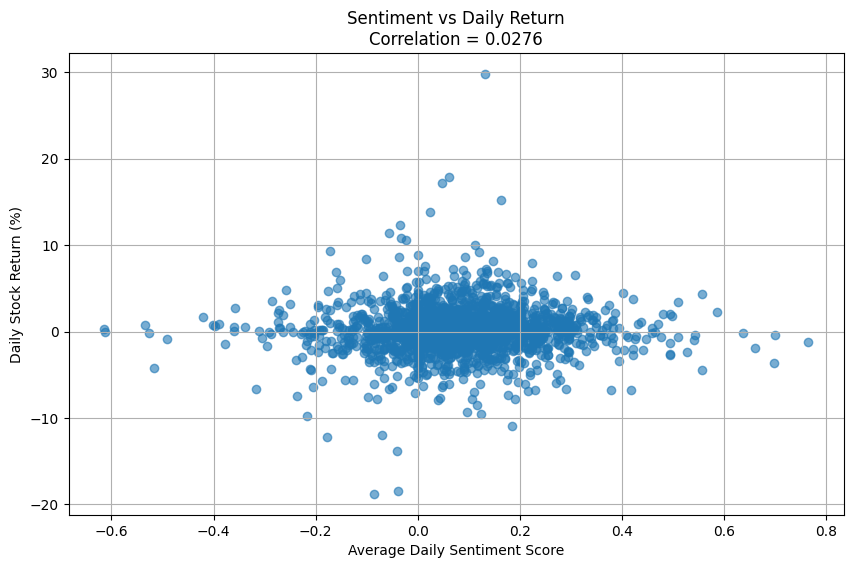

In [24]:
plt.figure(figsize=(10, 6))

plt.scatter(
    merged_df['sentiment_score'],
    merged_df['Daily_Return'],
    alpha=0.6
)

plt.title(
    f'Sentiment vs Daily Return\nCorrelation = {corr:.4f}'
)

plt.xlabel('Average Daily Sentiment Score')

plt.ylabel('Daily Stock Return (%)')

plt.grid(True)

plt.show()

## SENTIMENT CLASSIFICATION

In [25]:
def classify_sentiment(score):

    if score > 0.05:
        return 'Positive'

    elif score < -0.05:
        return 'Negative'

    else:
        return 'Neutral'

merged_df['Sentiment_Category'] = (
    merged_df['sentiment_score']
    .apply(classify_sentiment)
)

## AVERAGE RETURN BY SENTIMENT CATEGORY

In [26]:
category_returns = (
    merged_df
    .groupby('Sentiment_Category')['Daily_Return']
    .mean()
)

print()
print('AVERAGE RETURN BY SENTIMENT CATEGORY')
print('=' * 50)

print(category_returns)



AVERAGE RETURN BY SENTIMENT CATEGORY
Sentiment_Category
Negative   -0.296627
Neutral     0.202211
Positive    0.249903
Name: Daily_Return, dtype: float64


## Visualization

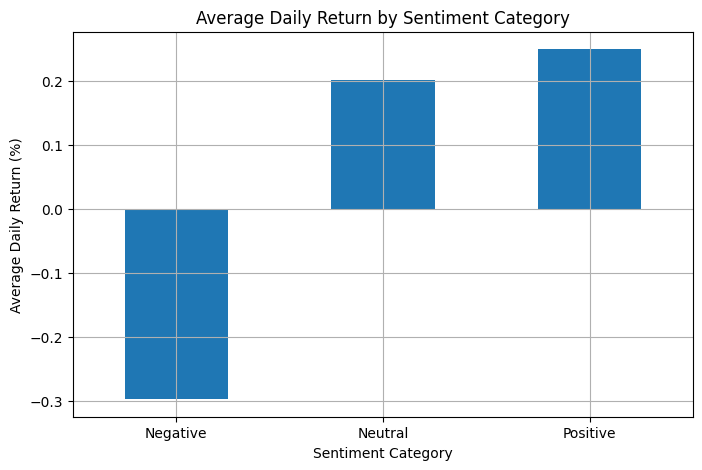

In [27]:
plt.figure(figsize=(8, 5))

category_returns.plot(kind='bar')

plt.title('Average Daily Return by Sentiment Category')

plt.ylabel('Average Daily Return (%)')

plt.xlabel('Sentiment Category')

plt.xticks(rotation=0)

plt.grid(True)

plt.show()

## Interpretation

As illustrated in the figure of Average Daily Return by Sentiment Category, the fact that "Positive" sentiment outperforms "Neutral" and "Negative" sentiments which suggests that the market may respond more favorably to spositive reporting or that positive news is frequently "priced in" at the time of the headlines break.

The broader relationship is captured in the scatter plot of Sentiment vs Daily Return figure, which shows a Pearson Correlation of 0.0276. While this indicates a very weak positive linear relationship, the p-value of 0.1930 is not significant metric. Because the p-value is above the conventional 0.05 threshold. It means that any observed relationship is likely due to random chance rather than a meaningful market trend.